In [1]:
import torch
import matplotlib.pyplot as plt


In [2]:
torch.manual_seed(1)

X = torch.linspace(-3, 3, 100).reshape(-1, 1)
Y = X**2


In [3]:
W = torch.randn(1, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)


In [4]:
vW = torch.zeros_like(W)
vb = torch.zeros_like(b)


In [5]:
losses_momentum = []

for epoch in range(100):
    pred = X @ W + b
    loss = torch.mean((pred - Y)**2)

    loss.backward()

    vW = 0.9*vW + 0.1*W.grad
    vb = 0.9*vb + 0.1*b.grad

    with torch.no_grad():
        W -= 0.01*vW
        b -= 0.01*vb

    W.grad.zero_()
    b.grad.zero_()

    losses_momentum.append(loss.item())

print("Momentum final loss:", losses_momentum[-1])

Momentum final loss: 7.5947957038879395


In [6]:
W = torch.randn(1, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

sW = torch.zeros_like(W)
sb = torch.zeros_like(b)

losses_rms = []

for epoch in range(100):
    pred = X @ W + b
    loss = torch.mean((pred - Y)**2)

    loss.backward()

    sW = 0.9*sW + 0.1*(W.grad**2)
    sb = 0.9*sb + 0.1*(b.grad**2)

    with torch.no_grad():
        W -= 0.01*W.grad/(torch.sqrt(sW)+1e-8)
        b -= 0.01*b.grad/(torch.sqrt(sb)+1e-8)

    W.grad.zero_()
    b.grad.zero_()

    losses_rms.append(loss.item())

print("RMSprop final loss:", losses_rms[-1])


RMSprop final loss: 11.53685188293457


Adam final loss: 12.029454231262207


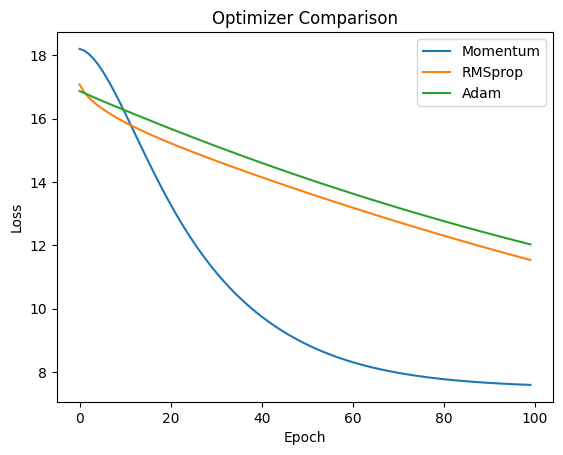

In [7]:
W = torch.randn(1, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

mW = torch.zeros_like(W)
mb = torch.zeros_like(b)
vW = torch.zeros_like(W)
vb = torch.zeros_like(b)

losses_adam = []

for epoch in range(1, 101):
    pred = X @ W + b
    loss = torch.mean((pred - Y)**2)

    loss.backward()

    mW = 0.9*mW + 0.1*W.grad
    mb = 0.9*mb + 0.1*b.grad

    vW = 0.999*vW + 0.001*(W.grad**2)
    vb = 0.999*vb + 0.001*(b.grad**2)

    mW_hat = mW/(1-0.9**epoch)
    mb_hat = mb/(1-0.9**epoch)
    vW_hat = vW/(1-0.999**epoch)
    vb_hat = vb/(1-0.999**epoch)

    with torch.no_grad():
        W -= 0.01*mW_hat/(torch.sqrt(vW_hat)+1e-8)
        b -= 0.01*mb_hat/(torch.sqrt(vb_hat)+1e-8)

    W.grad.zero_()
    b.grad.zero_()

    losses_adam.append(loss.item())

print("Adam final loss:", losses_adam[-1])

plt.plot(losses_momentum, label="Momentum")
plt.plot(losses_rms, label="RMSprop")
plt.plot(losses_adam, label="Adam")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Comparison")
plt.show()
